# EDA — the Nepanglish corpus: what it holds, who speaks, how it sounds, and where recognition breaks

Everything here is read from one file, `exports/analytics/analytics.jsonl` (`make export`), which
carries every labeled clip with its text, the three recognisers' transcripts and the fused seed,
the clip's crosstalk and VAD spans, its speaker turns from the diarizer with their linked voices
(D78, D79, D87), its acoustics (bandwidth, speech-to-noise ratio, C50), and its bucket on every
axis of `app/services/clip_classes.py`. The notebook runs no model of its own: voices come from
the harness's diarizer and cross-episode linking, which agree with the ECAPA voice prints an
earlier version of this notebook computed on every recurring host (docs/findings.md). It runs in
about two minutes on a CPU.

Nine questions, in this order:

1. **What is in the corpus?** Clips, hours, episodes and voices by split, and how each label was made.
2. **Where does the speech come from?** Genre, topic and show.
3. **Who is speaking, and for how long?** Talk time per voice, and gender and age per second of speech.
4. **How does the conversation go?** Crosstalk, speakers per clip, hand-overs, pauses.
5. **How does it sound?** Bandwidth, noise, room, clip length.
6. **How much do people mix languages, and how fast do they talk?**
7. **How were the labels made?** Tiers, dispositions, flags and the disagreement signal.
8. **How do the recognisers do**, by split and along every clip class?
9. **How much does it vary from voice to voice?**

**Read before quoting a WER.** Every reference started as the fused transcript of the same three
recognisers (D74). Gold was listened to clip by clip (4.6% edited); the rest was mostly screened
on the disagreement signal without being played. A recogniser's WER here is its distance from a
lightly checked fusion of all three, not from an independent transcription, and the fusion itself
scores near zero by construction. Differences *between strata* are more trustworthy than any
absolute level. A fine-tuned model's numbers, which are independent of the references, live on
the Models page and in docs/findings.md.

In [1]:
import json
import re
import sys
import time
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from rapidfuzz.distance import Levenshtein
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", category=FutureWarning)

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "backend"))
from app.services.fold import fold_tokens, fold_version, word_errors  # noqa: E402

ANALYTICS = REPO / "exports" / "analytics" / "analytics.jsonl"
FIGURES = REPO / "notebooks" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

SYSTEMS = ["elevenlabs-scribe-v2", "gemini-3.8-flash", "mai-transcribe-2"]
SEED = "fusion-gemini-3.8-flash-p1"
SHORT = {"elevenlabs-scribe-v2": "Scribe", "gemini-3.8-flash": "Gemini", "mai-transcribe-2": "MAI",
         SEED: "Fusion (seed)"}
# The first three slots of the reference categorical palette: the only three that stay
# distinguishable for every colour-vision type when all pairs are on screen at once. The seed is
# not a competitor, so it is drawn in ink grey.
SLOTS = ["#2a78d6", "#eb6834", "#1baf7a"]
SYS_COLOR = dict(zip(SYSTEMS, SLOTS)) | {SEED: "#8f8d86"}
SPLITS = ["train", "val", "gold"]
SPLIT_COLOR = dict(zip(SPLITS, SLOTS))
GENRES = ["podcast", "tech_review", "short"]
GENRE_COLOR = dict(zip(GENRES, SLOTS))
GENDER_COLOR = {"female": "#2a78d6", "male": "#eb6834", "unresolved": "#b9b7b0"}
RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]  # one hue, light -> dark
GREY = "#b9b7b0"
INK, MUTED = "#0b0b0b", "#52514e"
TIERS = ["Low (<10)", "Medium (10-30)", "Heavy (>=30)", "English only"]

plt.style.use("default")
plt.rcParams.update({
    "font.size": 9.5, "axes.titlesize": 10.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.edgecolor": "#c9c8c2", "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": "#ecebe7", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110, "legend.frameon": False,
})
_installed = {f.name for f in plt.matplotlib.font_manager.fontManager.ttflist}
DEVA_FONT = next((n for n in ("Noto Sans Devanagari", "Noto Serif Devanagari", "FreeSans")
                  if n in _installed), None)


def script_aware(texts):
    """Give labels that contain Devanagari a font list that can draw both scripts."""
    for text in texts:
        if DEVA_FONT and re.search(r"[ऀ-ॿ]", text.get_text()):
            text.set_fontfamily(["DejaVu Sans", DEVA_FONT])
    return texts


def save(fig, name):
    fig.savefig(FIGURES / f"eda_{name}.png", dpi=150, bbox_inches="tight")


def legend_patches(colors, labels=None):
    return [plt.Rectangle((0, 0), 1, 1, color=colors[k], label=(labels or {}).get(k, k)) for k in colors]


pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 140)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

manifest = json.loads((ANALYTICS.parent / "manifest.json").read_text())
rows, hyps, EP_META, talk = [], {}, {}, {}
with ANALYTICS.open(encoding="utf-8") as fh:
    for line in fh:
        r = json.loads(line)
        by_sys = {h["system_id"]: h for h in r["hypotheses"]}
        meta = r["episode_metadata"] or {}
        cls = r["classes"]
        ac = r["acoustics"] or {}
        vad = r["vad_spans"] or []
        speech = sum(b - a for a, b in vad)
        # Talk time per linked voice inside the clip, from the diarizer's turns (D78); an
        # unlinked speaker is dropped here, and a clip's own voice is its dominant one (D87).
        per_voice = defaultdict(float)
        for t in r["speaker_turns"] or []:
            if t["voice"]:
                per_voice[t["voice"]] += t["end"] - t["start"]
        talk[r["segment_id"]] = dict(per_voice)
        rows.append({
            "segment_id": r["segment_id"], "episode": r["episode_id"], "pot": r["pot"],
            "split": "gold" if r["pot"] == "gold" else r["split"],
            "tier": r["verification_tier"], "disposition": r["disposition"],
            "start": r["start_time"], "end": r["end_time"], "duration": r["duration_seconds"],
            # The gold reels were ingested without a genre; they are a genre of their own.
            "genre": meta.get("genre") or "short", "topic": meta.get("topic") or "unclassified",
            "declared": len(meta.get("speakers") or {}),
            "speech_s": speech, "pause_share": max(0.0, 1 - speech / r["duration_seconds"]),
            "overlap_s": sum(b - a for a, b in r["overlap_spans"]),
            "n_windows": len(r["overlap_spans"]),
            "bandwidth_hz": ac.get("bandwidth_hz"), "snr_db": ac.get("snr_db"), "c50_db": ac.get("c50_db"),
            "voice": None if cls["voice"] == "unlinked" else cls["voice"],
            **{f"c_{k}": v for k, v in cls.items() if k != "voice"},
            "flag_list": tuple((r["scores"] or {}).get("flags") or []),
            "disagreement": (r["scores"] or {}).get("word_disagreement_rate"),
            "spans_pots": r["episode_spans_pots"],
            "text": r["text"] or "",
        })
        hyps[r["segment_id"]] = {s: (by_sys.get(s) or {}).get("text") or "" for s in SHORT}
        EP_META.setdefault(r["episode_id"], meta)

seg = pd.DataFrame(rows).set_index("segment_id")
seg["overlap_share"] = (seg.overlap_s / seg.duration).clip(upper=1)
usable = seg[seg.disposition.isin(["accepted_unchanged", "edited"])]
print(f"{len(seg):,} labeled clips, {seg.duration.sum() / 3600:.2f} h, {seg.episode.nunique()} episodes, "
      f"{seg.voice.nunique()} voices lead a clip | fold {fold_version()} | exported {manifest['exported_at'][:10]} "
      f"at harness {manifest['git_commit'][:7]}")
print(f"{len(seg) - len(usable)} clips are 'uncertain' or 'unusable_audio' and stay out of every rate below")

7,581 labeled clips, 26.69 h, 126 episodes, 119 voices lead a clip | fold fold-v3+norm-v3 | exported 2026-09-18 at harness 0a60c95
24 clips are 'uncertain' or 'unusable_audio' and stay out of every rate below


## Scoring every clip

Three numbers per clip and recogniser, each summed over clips as errors / reference units (never
a mean of per-clip rates, which would let a 3-word clip count as much as a 60-word one):

- **WER** — script-folded, through `app/services/fold.py`: `टिम` and `team` are the same word,
  `गर्नुभयो`/`गर्नु भयो` is one, and since fold-v3 so are the colloquial and standard forms of a
  verb (D89). This is the harness's WER and the headline everywhere below.
- **raw WER** — plain token match. The gap to WER is how much a recogniser loses to *spelling*.
- **CER** — character edit distance on the raw tokens. It cannot see across scripts, so a
  recogniser that writes English in Devanagari pays for it here in full.

The fused seed is scored too, as a control: it is what every reference started from, so its
distance from the reference is the edit rate, not an accuracy. Also per clip: **CMI** from the
reference (Devanagari vs Latin tokens; numbers are neutral) and **speaking rate** in words per
second of VAD speech, so a pause does not count as slow talking.

In [2]:
DEV = re.compile(r"[ऀ-ॿ]")
LAT = re.compile(r"[A-Za-z]")


def chars(text):
    """The words fold.py compares, Latin lowercased, joined by single spaces: what CER is over."""
    return " ".join(t if DEV.search(t) else t.lower() for t in fold_tokens(text))


def score(ids, refs, hyp_rows):
    out = []
    for sid, ref, hy in zip(ids, refs, hyp_rows):
        toks = fold_tokens(ref)
        n_dev = sum(bool(DEV.search(t)) for t in toks)
        n_lat = sum(bool(LAT.search(t)) and not DEV.search(t) for t in toks)
        rec = {"segment_id": sid, "words": len(toks), "n_dev": n_dev, "n_lat": n_lat,
               "ref_chars": len(chars(ref))}
        for s in SHORT:
            rec[f"{s}|werr"] = word_errors(ref, hy[s]).errors
            raw = word_errors(ref, hy[s], folded=False)
            rec[f"{s}|rerr"], rec[f"{s}|rwords"] = raw.errors, raw.ref_words
            rec[f"{s}|cerr"] = Levenshtein.distance(chars(ref), chars(hy[s]))
        out.append(rec)
    return out


t0 = time.time()
ids = seg.index.tolist()
chunks = np.array_split(np.arange(len(ids)), 64)
parts = Parallel(n_jobs=-1)(
    delayed(score)([ids[i] for i in c], [seg.text.iat[i] for i in c], [hyps[ids[i]] for i in c])
    for c in chunks
)
seg = seg.join(pd.DataFrame([r for p in parts for r in p]).set_index("segment_id"))
print(f"scored {len(seg):,} clips x {len(SHORT)} systems in {time.time() - t0:.1f}s")

n_mixed = seg.n_dev + seg.n_lat
seg["cmi"] = np.where(n_mixed > 0, 100 * (n_mixed - np.maximum(seg.n_dev, seg.n_lat)) / n_mixed.clip(lower=1), 0.0)
seg["cmi_tier"] = np.select(
    [(seg.n_dev == 0) & (seg.n_lat > 0), seg.cmi < 10, seg.cmi < 30], [TIERS[3], TIERS[0], TIERS[1]],
    default=TIERS[2],
)
seg["rate"] = seg.words / seg.speech_s.where(seg.speech_s >= 1.0, seg.duration)
scored = seg[(seg.words > 0) & seg.disposition.isin(["accepted_unchanged", "edited"])].copy()
scored["cluster"] = scored.voice.fillna("ep:" + scored.episode)
print(f"{len(seg) - len(scored):,} clips left out of every rate: empty reference, uncertain or unusable")


def wer_table(frame, cluster="cluster", n_boot=2000, seed=0, systems=SYSTEMS):
    """Corpus-level WER / raw WER / CER per system, with a 95% CI on WER that resamples
    ``cluster`` (voices by default): clips of one voice are not independent draws."""
    out = {}
    for s in systems:
        row = {
            "WER %": 100 * frame[f"{s}|werr"].sum() / frame.words.sum(),
            "raw WER %": 100 * frame[f"{s}|rerr"].sum() / frame[f"{s}|rwords"].sum(),
            "CER %": 100 * frame[f"{s}|cerr"].sum() / frame.ref_chars.sum(),
        }
        if cluster is not None:
            g = frame.groupby(cluster).agg(e=(f"{s}|werr", "sum"), w=("words", "sum"))
            rng = np.random.default_rng(seed)
            pick = rng.integers(0, len(g), size=(n_boot, len(g)))
            boot = 100 * g.e.to_numpy()[pick].sum(axis=1) / g.w.to_numpy()[pick].sum(axis=1)
            row["WER lo"], row["WER hi"] = np.percentile(boot, [2.5, 97.5])
        out[SHORT[s]] = row
    return pd.DataFrame(out).T


overall = wer_table(scored, systems=list(SHORT))
display(overall)
print(f"the seed's {overall.loc['Fusion (seed)', 'WER %']:.2f}% is how far the labels moved from it "
      f"({int((scored.disposition == 'edited').sum())} edited clips), not an accuracy")

scored 7,581 clips x 4 systems in 49.8s
26 clips left out of every rate: empty reference, uncertain or unusable


,WER %,raw WER %,CER %,WER lo,WER hi
Scribe,10.12,19.01,9.76,8.12,12.12
Gemini,9.27,20.27,10.48,7.38,11.15
MAI,10.15,19.32,10.66,7.59,12.66
Fusion (seed),0.00,0.22,0.01,0.00,0.01


the seed's 0.00% is how far the labels moved from it (26 edited clips), not an accuracy


## 1. What is in the corpus

Three pots of clips: **train** and **val** are whole episodes drawn by stratum (D90), **gold** is
chosen clip by clip by hand (D71) and, since 2026-09-16, comes only from short recordings whose
voices appear nowhere else (roadmap item 5). A clip's tier says how hard its label was looked at:
**verified** was played and read, **screened** was accepted on the disagreement signal (D63).

,episodes,clips,hours,voices,median clip s,verified %,edited,crosstalk % of audio
split,,,,,,,,
train,38.00,"6,417.00",22.30,30.00,13.61,16.86,3.00,3.26
val,6.00,635.00,2.18,5.00,13.63,14.96,0.00,1.06
gold,82.00,505.00,2.17,87.00,17.51,100.00,23.00,0.48
all,126.00,"7,557.00",26.65,119.00,14.09,22.26,26.00,2.85


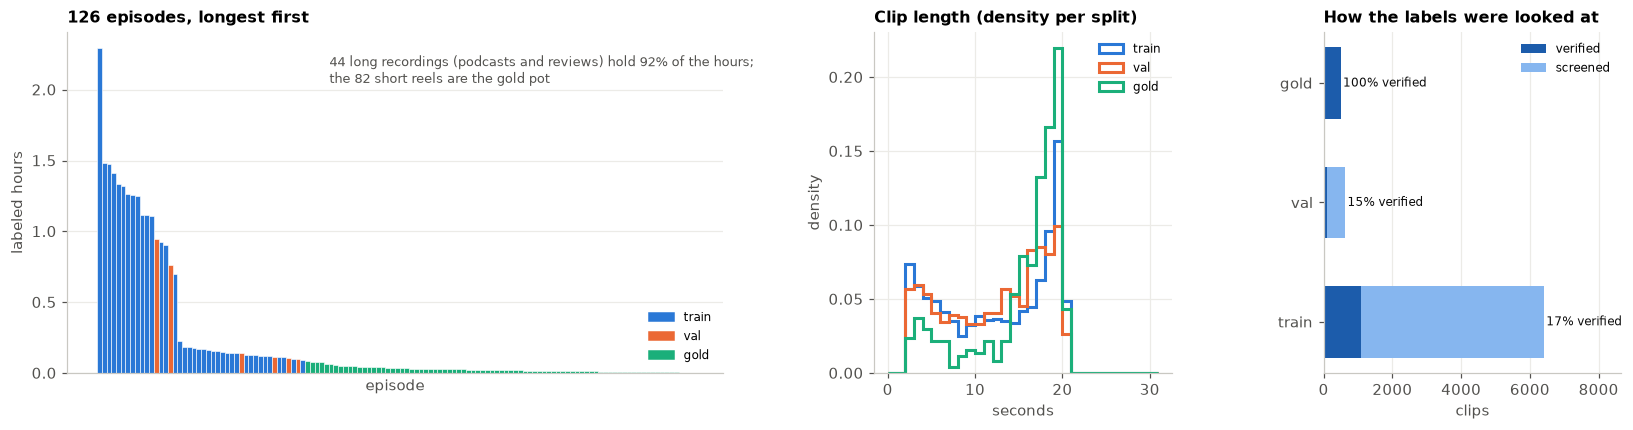

In [3]:
def hours(frame, col):
    return frame.groupby(col, observed=True).duration.sum().div(3600)


at_a_glance = pd.DataFrame({
    "episodes": usable.groupby("split").episode.nunique(),
    "clips": usable.groupby("split").size(),
    "hours": hours(usable, "split"),
    "voices": usable.groupby("split").voice.nunique(),
    "median clip s": usable.groupby("split").duration.median(),
    "verified %": 100 * usable.groupby("split").tier.apply(lambda s: (s == "verified").mean()),
    "edited": usable.groupby("split").disposition.apply(lambda s: int((s == "edited").sum())),
    "crosstalk % of audio": 100 * usable.groupby("split").overlap_s.sum() / usable.groupby("split").duration.sum(),
}).reindex(SPLITS)
at_a_glance.loc["all"] = [usable.episode.nunique(), len(usable), usable.duration.sum() / 3600, usable.voice.nunique(),
                          usable.duration.median(), 100 * (usable.tier == "verified").mean(),
                          int((usable.disposition == "edited").sum()), 100 * usable.overlap_s.sum() / usable.duration.sum()]
display(at_a_glance)

ep = usable.groupby("episode").agg(split=("split", "first"), genre=("genre", "first"), hours=("duration", lambda d: d.sum() / 3600),
                                   clips=("duration", "size")).sort_values("hours", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), gridspec_kw={"width_ratios": [2.2, 1, 1]})
ax = axes[0]
ax.bar(range(len(ep)), ep.hours, color=[SPLIT_COLOR[s] for s in ep.split], width=1.0, edgecolor="white", linewidth=0.4)
ax.set(title=f"{len(ep)} episodes, longest first", xlabel="episode", ylabel="labeled hours")
ax.set_xticks([])
ax.legend(handles=legend_patches(SPLIT_COLOR), fontsize=8)
n_long = int((ep.genre != "short").sum())
ax.annotate(f"{n_long} long recordings (podcasts and reviews) hold {ep.hours[ep.genre != 'short'].sum() / ep.hours.sum():.0%} of the hours;\n"
            f"the {len(ep) - n_long} short reels are the gold pot", xy=(0.4, 0.85), xycoords="axes fraction", fontsize=8.5, color=MUTED)

ax = axes[1]
bins = np.arange(0, 32, 1)
for s in SPLITS:
    ax.hist(usable.duration[usable.split == s].clip(upper=31), bins=bins, density=True, histtype="step", lw=2, color=SPLIT_COLOR[s], label=s)
ax.set(title="Clip length (density per split)", xlabel="seconds", ylabel="density")
ax.legend(fontsize=8)

ax = axes[2]
tiers = usable.groupby(["split", "tier"]).size().unstack(fill_value=0).reindex(SPLITS)
left = np.zeros(len(SPLITS))
for tier, color in (("verified", "#1c5cab"), ("screened", "#86b6ef")):
    ax.barh(SPLITS, tiers[tier], left=left, color=color, label=tier, height=0.6)
    left += tiers[tier].to_numpy()
for y, s in enumerate(SPLITS):
    ax.text(left[y] + 60, y, f"{100 * tiers.loc[s, 'verified'] / tiers.loc[s].sum():.0f}% verified", va="center", fontsize=8, color=INK)
ax.set(title="How the labels were looked at", xlabel="clips")
ax.set_xlim(0, left.max() * 1.35)
ax.grid(axis="y", visible=False)
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
save(fig, "01_corpus")
plt.show()

## 2. Where the speech comes from

Genre is declared at ingest; the topic is classified from the transcript by an LLM (D57). A show
is read off the episode id: the three podcast series each have one recurring host, the tech
reviews are one channel's, and the reels are the gold pot.

,episodes,hours,clips,voices,declared speakers / episode,split
show,,,,,,
ep_NNN podcast,5,7.40,2048,10,2.80,train
other podcasts,7,6.61,2092,12,1.71,train
On Air with Sanjay,5,5.45,1710,7,2.20,"train, val"
tech reviews,25,3.55,689,1,1.00,"train, val"
gold reels,82,2.17,505,87,0.00,gold
Bravo Delta Show,2,1.47,513,3,2.00,"train, val"


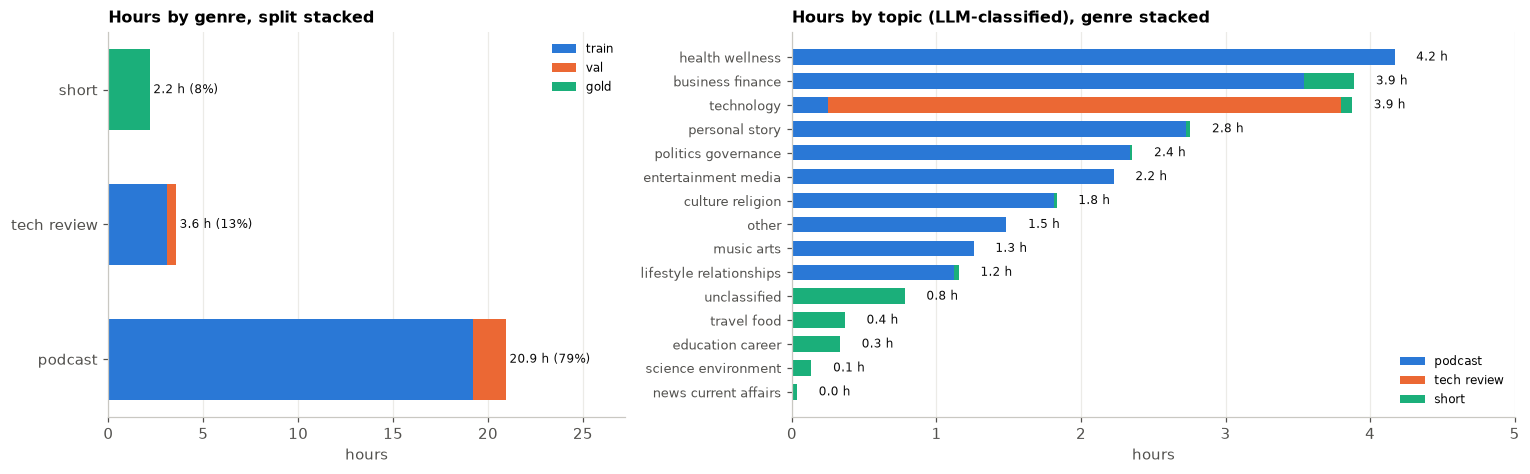

topics: 15; the top three hold 45% of the hours


In [4]:
def show(ep_id):
    meta = EP_META[ep_id]
    if not meta.get("genre"):
        return "gold reels"
    if meta["genre"] == "tech_review":
        return "tech reviews"
    for prefix, name in (("on_air_with_sanjay_", "On Air with Sanjay"), ("the_bravo_delta_show_", "Bravo Delta Show")):
        if ep_id.startswith(prefix):
            return name
    return "ep_NNN podcast" if re.match(r"ep_\d+_", ep_id) else "other podcasts"


usable = usable.assign(show=usable.episode.map(show))
scored["show"] = scored.episode.map(show)
shows = pd.DataFrame({
    "episodes": usable.groupby("show").episode.nunique(),
    "hours": hours(usable, "show"),
    "clips": usable.groupby("show").size(),
    "voices": usable.groupby("show").voice.nunique(),
    "declared speakers / episode": usable.groupby("show").apply(lambda f: f.groupby("episode").declared.first().mean()),
    "split": usable.groupby("show").split.agg(lambda s: ", ".join(sorted(set(s)))),
}).sort_values("hours", ascending=False)
display(shows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), gridspec_kw={"width_ratios": [1, 1.4]})
ax = axes[0]
g = usable.groupby(["genre", "split"]).duration.sum().div(3600).unstack(fill_value=0).reindex(GENRES).reindex(columns=SPLITS, fill_value=0)
left = np.zeros(len(GENRES))
for s in SPLITS:
    ax.barh(GENRES, g[s], left=left, color=SPLIT_COLOR[s], label=s, height=0.6)
    left += g[s].to_numpy()
for y, v in enumerate(left):
    ax.text(v + 0.2, y, f"{v:.1f} h ({v / left.sum():.0%})", va="center", fontsize=8, color=INK)
ax.set(title="Hours by genre, split stacked", xlabel="hours")
ax.set_xlim(0, left.max() * 1.3)
ax.set_yticks(range(len(GENRES)), [g_.replace("_", " ") for g_ in GENRES])
ax.grid(axis="y", visible=False)
ax.legend(fontsize=8, loc="upper right")

ax = axes[1]
topic_h = usable.groupby(["topic", "genre"]).duration.sum().div(3600).unstack(fill_value=0).reindex(columns=GENRES, fill_value=0)
topic_h = topic_h.loc[topic_h.sum(axis=1).sort_values().index]
left = np.zeros(len(topic_h))
for g_ in GENRES:
    ax.barh(topic_h.index, topic_h[g_], left=left, color=GENRE_COLOR[g_], label=g_.replace("_", " "), height=0.65)
    left += topic_h[g_].to_numpy()
for y, v in enumerate(left):
    ax.text(v + 0.15, y, f"{v:.1f} h", va="center", fontsize=8, color=INK)
ax.set(title="Hours by topic (LLM-classified), genre stacked", xlabel="hours")
ax.set_yticks(range(len(topic_h)), [i.replace("_", " ") for i in topic_h.index], fontsize=8.5)
ax.set_xlim(0, left.max() * 1.2)
ax.grid(axis="y", visible=False)
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
save(fig, "02_genre_topic")
plt.show()
print(f"topics: {topic_h.index.size}; the top three hold {topic_h.sum(axis=1).sort_values(ascending=False).head(3).sum() / topic_h.sum().sum():.0%} of the hours")

## 3. Who is speaking, and for how long

**Method.** pyannote diarizes every episode at ingest at its declared speaker count (D79); each
speaker's embedding is linked across episodes into an anonymous voice at cosine 0.6 (D87). A
clip's talk time per voice is the sum of that voice's turns inside the clip, so a two-speaker clip
is split rather than credited to one person. Voices are anonymous by design: no name, and no
gender or age is ever inferred from audio (D56, D58).

**Gender and age per second of speech** come from the declared speaker rows of the episode
metadata, which the harness never links to a voice (D78). A voice inherits a declared row only when
the assignment is forced:

1. every declared speaker of the episode shares the value (the harness's own class);
2. the episode declares one host, and exactly one of its voices recurs in other episodes: that
   voice is the host, and a single voice left with a single row left takes it;
3. as many voices as rows are left and the rows all share a gender (or an age): that much is
   known for each of them.

Anything else stays unresolved rather than guessed. The gold reels declare nobody.

In [5]:
voice_talk = defaultdict(lambda: defaultdict(float))  # voice -> split -> seconds
voice_eps = defaultdict(set)
for sid, per in talk.items():
    if sid not in usable.index:
        continue
    for v, sec in per.items():
        voice_talk[v][usable.split[sid]] += sec
        voice_eps[v].add(usable.episode[sid])
VOICES = sorted(voice_talk)
n_eps = {v: len(voice_eps[v]) for v in VOICES}

resolved = {}  # (episode, voice) -> declared row
how = Counter()
for ep_id, meta in EP_META.items():
    rows_ = list((meta.get("speakers") or {}).values())
    present = sorted({v for v in usable.voice[usable.episode == ep_id].dropna()})
    if not rows_ or not present:
        continue
    genders, ages = {r.get("gender") for r in rows_}, {r.get("age_bracket") for r in rows_}
    if len(genders) == 1 and len(ages) == 1 and len(rows_) >= 1:
        for v in present:
            resolved[(ep_id, v)] = rows_[0]
        how["whole episode agrees"] += len(present)
        continue
    hosts = [r for r in rows_ if r.get("role") == "host"]
    recurring = [v for v in present if n_eps[v] > 1]
    left_rows, left_voices = list(rows_), list(present)
    if len(hosts) == 1 and len(recurring) == 1:
        resolved[(ep_id, recurring[0])] = hosts[0]
        left_rows.remove(hosts[0]); left_voices.remove(recurring[0])
        how["series host"] += 1
    if len(left_rows) == 1 and len(left_voices) == 1:
        resolved[(ep_id, left_voices[0])] = left_rows[0]
        how["last row"] += 1
    elif left_rows and len(left_rows) == len(left_voices):
        shared = {k: next(iter(vals)) for k in ("gender", "age_bracket")
                  if len(vals := {r.get(k) for r in left_rows}) == 1 and None not in vals}
        if shared:
            for v in left_voices:
                resolved[(ep_id, v)] = shared
            how["shared rows"] += len(left_voices)


def agree(values):
    vals = {v for v in values if v}
    return vals.pop() if len(vals) == 1 else "unresolved"


SPK = pd.DataFrame([{
    "voice": v, "episodes": n_eps[v], "talk_min": sum(voice_talk[v].values()) / 60,
    **{f"{s}_min": voice_talk[v].get(s, 0.0) / 60 for s in SPLITS},
    "split": ", ".join(s for s in SPLITS if voice_talk[v].get(s, 0) > 0),
    "gender": agree(resolved.get((e, v), {}).get("gender") for e in voice_eps[v]),
    "age": agree(resolved.get((e, v), {}).get("age_bracket") for e in voice_eps[v]),
    "show": ", ".join(sorted({show(e) for e in voice_eps[v]})),
} for v in VOICES]).set_index("voice").sort_values("talk_min", ascending=False)
SPK["share %"] = 100 * SPK.talk_min / SPK.talk_min.sum()
shared = SPK[(SPK.gold_min > 0) & (SPK.train_min + SPK.val_min > 0)]
print(f"{len(SPK)} voices: {int((SPK.gold_min > 0).sum())} speak in gold, {int((SPK.train_min > 0).sum())} in train, "
      f"{int((SPK.val_min > 0).sum())} in val; {len(shared)} speak on both sides of the gold line")
print(f"resolution: {dict(how)}; gender known for {(SPK.gender != 'unresolved').mean():.0%} of voices and "
      f"{SPK.talk_min[SPK.gender != 'unresolved'].sum() / SPK.talk_min.sum():.0%} of talk time")
display(SPK.head(40))

125 voices: 93 speak in gold, 30 in train, 5 in val; 0 speak on both sides of the gold line
resolution: {'whole episode agrees': 43, 'series host': 6, 'last row': 5, 'shared rows': 12}; gender known for 24% of voices and 87% of talk time


,episodes,talk_min,train_min,val_min,gold_min,split,gender,age,show,share %
voice,,,,,,,,,,
v001,26,219.06,191.60,27.46,0.00,"train, val",female,20_39,"other podcasts, tech reviews",14.57
v003,5,118.19,118.19,0.00,0.00,train,male,20_39,ep_NNN podcast,7.86
v008,5,79.76,67.82,11.94,0.00,"train, val",male,40_59,On Air with Sanjay,5.31
v007,1,62.14,62.14,0.00,0.00,train,male,60_79,On Air with Sanjay,4.13
v024,1,54.67,54.67,0.00,0.00,train,male,unresolved,other podcasts,3.64
v002,1,53.79,53.79,0.00,0.00,train,male,20_39,ep_NNN podcast,3.58
v006,1,53.60,53.60,0.00,0.00,train,male,20_39,ep_NNN podcast,3.57
v005,1,49.93,49.93,0.00,0.00,train,female,40_59,ep_NNN podcast,3.32
v009,1,49.68,49.68,0.00,0.00,train,male,20_39,On Air with Sanjay,3.30


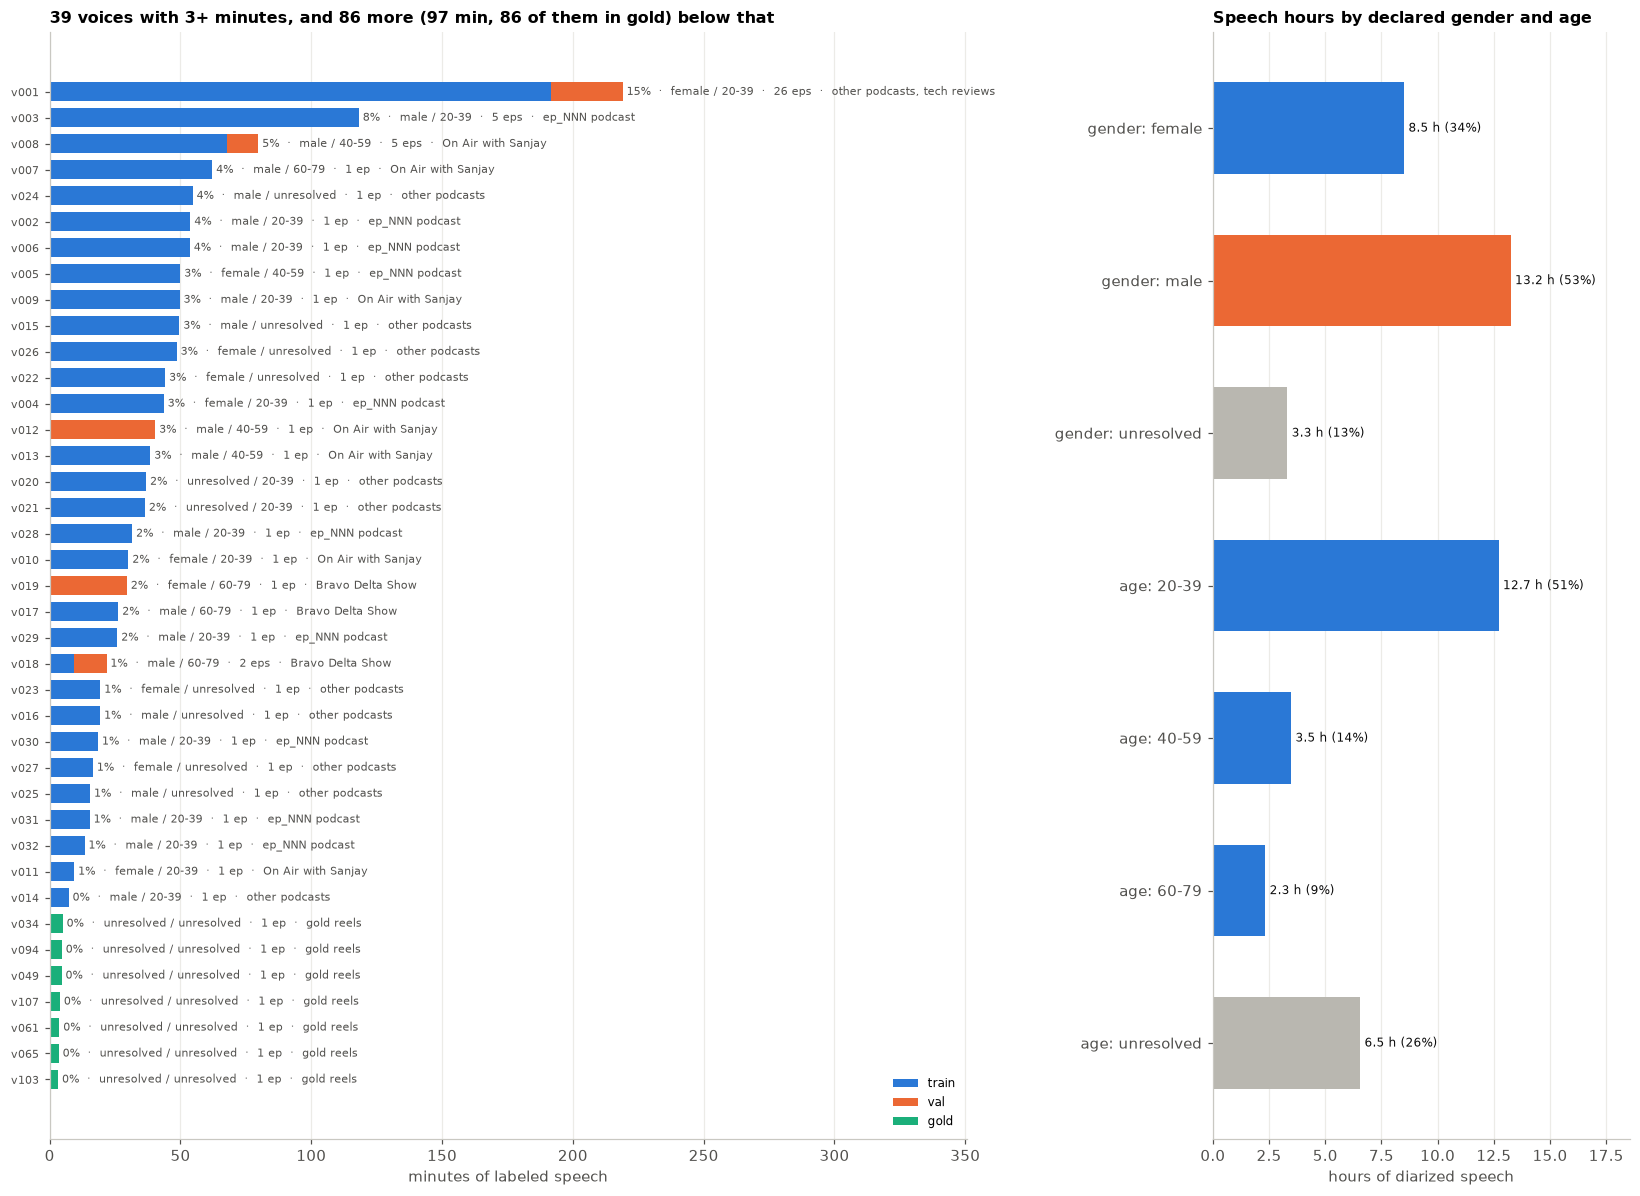

The largest voice (v001, other podcasts, tech reviews) holds 15% of the speech; the top 5 hold 36%. Median voice: 1.5 min; median train voice 37 min, median gold voice 1.0 min.


In [6]:
big = SPK[SPK.talk_min >= 3]
rest = SPK[SPK.talk_min < 3]
fig, axes = plt.subplots(1, 2, figsize=(15, 0.24 * len(big) + 1.6), gridspec_kw={"width_ratios": [2.2, 1]})
ax = axes[0]
order = big.iloc[::-1]
left = np.zeros(len(order))
for s in SPLITS:
    ax.barh(range(len(order)), order[f"{s}_min"], left=left, color=SPLIT_COLOR[s], label=s, height=0.72)
    left += order[f"{s}_min"].to_numpy()
for y, (v, r) in enumerate(order.iterrows()):
    ax.text(r.talk_min + 1.5, y, f"{r['share %']:.0f}%  ·  {r.gender} / {r.age.replace('_', '-')}  ·  "
            f"{r.episodes} ep{'s' if r.episodes > 1 else ''}  ·  {r.show}", va="center", fontsize=7.5, color=MUTED)
ax.set_yticks(range(len(order)), order.index, fontsize=7.5)
ax.set(xlabel="minutes of labeled speech", title=f"{len(big)} voices with 3+ minutes, and {len(rest)} more "
       f"({rest.talk_min.sum():.0f} min, {int((rest.gold_min > 0).sum())} of them in gold) below that")
ax.set_xlim(0, order.talk_min.max() * 1.6)
ax.grid(axis="y", visible=False)
ax.legend(fontsize=8, loc="lower right")

# Per second of speech, not per episode: a mixed podcast splits between its host and guest.
sec = defaultdict(lambda: defaultdict(float))
for sid, per in talk.items():
    if sid in usable.index:
        for v, s_ in per.items():
            sec["gender"][SPK.gender[v]] += s_
            sec["age"][SPK.age[v]] += s_
ax = axes[1]
labels, vals, colors = [], [], []
for key, order_ in (("gender", ["female", "male", "unresolved"]),
                    ("age", ["20_39", "40_59", "60_79", "unresolved"])):
    for k in order_:
        if sec[key].get(k):
            labels.append(f"{key}: {k.replace('_', '-')}"); vals.append(sec[key][k] / 3600)
            colors.append(GENDER_COLOR.get(k, RAMP[2] if key == "age" else GREY) if k != "unresolved" else GREY)
tot = sum(sec["gender"].values()) / 3600
ax.barh(labels[::-1], vals[::-1], color=colors[::-1], height=0.6)
for y, v in enumerate(vals[::-1]):
    ax.text(v + 0.2, y, f"{v:.1f} h ({v / tot:.0%})", va="center", fontsize=8, color=INK)
ax.set(title="Speech hours by declared gender and age", xlabel="hours of diarized speech")
ax.set_xlim(0, max(vals) * 1.4)
ax.grid(axis="y", visible=False)
fig.tight_layout()
save(fig, "03_voices")
plt.show()
top = SPK.iloc[0]
print(f"The largest voice ({top.name}, {top.show}) holds {top['share %']:.0f}% of the speech; the top 5 hold "
      f"{SPK['share %'].head(5).sum():.0f}%. Median voice: {SPK.talk_min.median():.1f} min; median train voice "
      f"{SPK.talk_min[SPK.train_min > 0].median():.0f} min, median gold voice {SPK.talk_min[SPK.gold_min > 0].median():.1f} min.")

## 4. How the conversation goes

Four classes from the stored spans (D87): **crosstalk** is the share of the clip where the overlap
detector hears two or more people at once (D77); **speakers** counts the diarized voices with at
least 0.5 s of talk in the clip; **hand-overs** are how often the floor changes; **pause** is the
share of the clip outside VAD speech. Crosstalk is the largest measured source of a fine-tuned
model's errors, and rapid hand-overs the second (docs/findings.md), so how much of each split
carries them is what makes a split's WER comparable with another's.

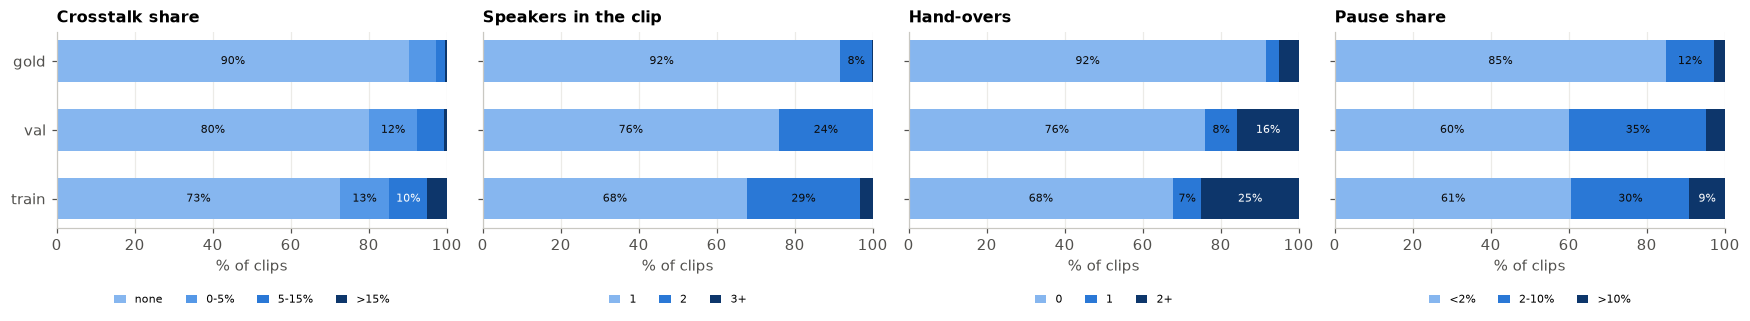

crosstalk: 26% of clips carry some, 17% half a second or more; 2.9% of all audio. Per split: train 3.3%, val 1.1%, gold 0.5%
an overlapped clip has a median 2 windows totalling 0.79 s (5% of the clip); p90 20%
speakers: 30% of clips have a second voice with 0.5 s or more; hand-overs: 23% of clips change speaker twice or more


In [7]:
AXES = {
    "c_overlap": ("Crosstalk share", ["none", "0-5%", "5-15%", ">15%"]),
    "c_speakers": ("Speakers in the clip", ["1", "2", "3+"]),
    "c_turn_changes": ("Hand-overs", ["0", "1", "2+"]),
    "c_pause": ("Pause share", ["<2%", "2-10%", ">10%"]),
    "c_snr": ("Speech-to-noise", ["<15 dB", "15-25 dB", "25-35 dB", "35-45 dB", "45+ dB"]),
    "c_reverb": ("Room (C50)", ["<40 dB", "40-50 dB", "50-55 dB", "55+ dB"]),
    "c_bandwidth": ("Bandwidth", ["<4.5 kHz", "4.5-6.5 kHz", "6.5+ kHz"]),
    "c_duration": ("Clip length", ["<5 s", "5-15 s", "15+ s"]),
    "c_cmi": ("CMI", ["0", "<15", "15-30", "30+"]),
}


def share_by_split(col, buckets):
    t = usable.groupby(["split", col]).size().unstack(fill_value=0).reindex(SPLITS).reindex(columns=buckets, fill_value=0)
    return t.div(t.sum(axis=1), axis=0) * 100


def stacked_share(ax, col, title, buckets):
    t = share_by_split(col, buckets)
    left = np.zeros(len(SPLITS))
    for i, b in enumerate(buckets):
        ax.barh(SPLITS, t[b], left=left, color=RAMP[i * (len(RAMP) - 1) // max(len(buckets) - 1, 1)], label=b, height=0.6)
        for y, v in enumerate(t[b]):
            if v >= 7:
                ax.text(left[y] + v / 2, y, f"{v:.0f}%", ha="center", va="center", fontsize=7.5,
                        color="white" if i >= len(buckets) / 2 else INK)
        left += t[b].to_numpy()
    ax.set(title=title, xlim=(0, 100), xlabel="% of clips")
    ax.grid(axis="y", visible=False)
    ax.legend(fontsize=7.5, loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=len(buckets), handlelength=1)


fig, axes = plt.subplots(1, 4, figsize=(16, 3.2), sharey=True)
for ax, col in zip(axes, ["c_overlap", "c_speakers", "c_turn_changes", "c_pause"]):
    stacked_share(ax, col, *AXES[col])
fig.tight_layout()
save(fig, "04_conversation")
plt.show()

ov = usable[usable.overlap_s > 0]
print(f"crosstalk: {len(ov) / len(usable):.0%} of clips carry some, {(usable.overlap_s >= 0.5).mean():.0%} half a second or more; "
      f"{100 * usable.overlap_s.sum() / usable.duration.sum():.1f}% of all audio. Per split: "
      + ", ".join(f"{s} {100 * usable.overlap_s[usable.split == s].sum() / usable.duration[usable.split == s].sum():.1f}%" for s in SPLITS))
print(f"an overlapped clip has a median {ov.n_windows.median():.0f} windows totalling {ov.overlap_s.median():.2f} s "
      f"({100 * ov.overlap_share.median():.0f}% of the clip); p90 {100 * ov.overlap_share.quantile(0.9):.0f}%")
print(f"speakers: {(usable.c_speakers != '1').mean():.0%} of clips have a second voice with 0.5 s or more; "
      f"hand-overs: {(usable.c_turn_changes == '2+').mean():.0%} of clips change speaker twice or more")

## 5. How it sounds

Measured at ingest on the 16 kHz clip (D87): **bandwidth** is where the spectrum falls off, so
narrow-band audio (a phone line, a compressed upload) shows below 4.5 kHz; **speech-to-noise
ratio** and **C50** (early-to-late energy: a dry room is 55+ dB, a reverberant one under 40) come
from Brouhaha over the frames it calls speech. A second voice is noise to Brouhaha, so a low SNR
in a podcast is often crosstalk rather than background (docs/findings.md). Clipping is not
measured: the stored audio is resampled before anything reads it.

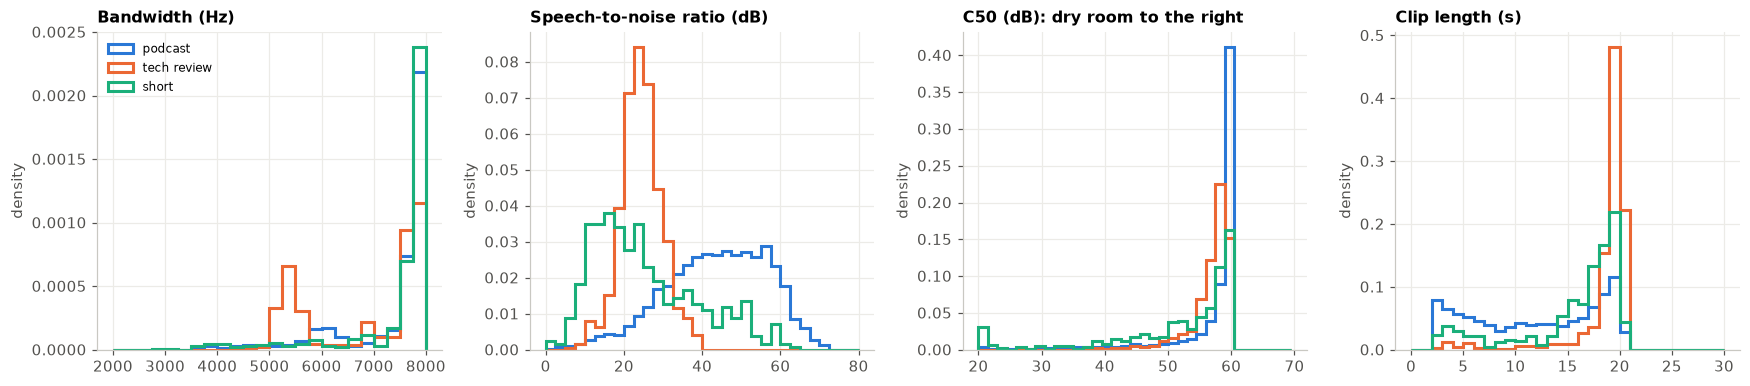

median bandwidth Hz  median SNR dB  median C50 dB  median clip s
by split train                   7,718.80          43.00          59.30          13.61
         val                     7,781.20          39.60          59.10          13.63
         gold                    7,750.00          22.30          55.90          17.51
by genre podcast                 7,750.00          44.50          59.40          12.38
         tech_review             7,625.00          24.20          57.80          19.57
         short                   7,750.00          22.30          55.90          17.51

noisiest episodes (median SNR): free_movies 8 dB, qr_in_ms_word 8 dB, citation_tool 8 dB
most reverberant (median C50): bachelor 14 dB, house_on_sell 14 dB, aata_bread 20 dB
narrow-band (<4.5 kHz): 175 clips in 18 episodes; 1296 more between 4.5 and 6.5 kHz


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
panels = [
    ("bandwidth_hz", np.arange(2000, 8100, 250), "Bandwidth (Hz)"),
    ("snr_db", np.arange(0, 81, 2.5), "Speech-to-noise ratio (dB)"),
    ("c50_db", np.arange(20, 71, 1.5), "C50 (dB): dry room to the right"),
    ("duration", np.arange(0, 31, 1), "Clip length (s)"),
]
for ax, (col, bins, title) in zip(axes, panels):
    for g_ in GENRES:
        v = usable.loc[usable.genre == g_, col].dropna().clip(bins[0], bins[-1])
        ax.hist(v, bins=bins, density=True, histtype="step", lw=2, color=GENRE_COLOR[g_], label=g_.replace("_", " "))
    ax.set(title=title, ylabel="density")
axes[0].legend(fontsize=8, loc="upper left")
fig.tight_layout()
save(fig, "05_acoustics")
plt.show()

acoustic = pd.concat({
    "by split": usable.groupby("split")[["bandwidth_hz", "snr_db", "c50_db", "duration"]].median().reindex(SPLITS),
    "by genre": usable.groupby("genre")[["bandwidth_hz", "snr_db", "c50_db", "duration"]].median().reindex(GENRES),
})
acoustic.columns = ["median bandwidth Hz", "median SNR dB", "median C50 dB", "median clip s"]
display(acoustic)
by_ep = usable.groupby("episode").agg(snr=("snr_db", "median"), c50=("c50_db", "median"), bw=("bandwidth_hz", "median"),
                                      genre=("genre", "first"), clips=("duration", "size"))
print("noisiest episodes (median SNR):", ", ".join(f"{e} {r.snr:.0f} dB" for e, r in by_ep.nsmallest(3, "snr").iterrows()))
print("most reverberant (median C50):", ", ".join(f"{e} {r.c50:.0f} dB" for e, r in by_ep.nsmallest(3, "c50").iterrows()))
print(f"narrow-band (<4.5 kHz): {(usable.c_bandwidth == '<4.5 kHz').sum()} clips in "
      f"{usable.episode[usable.c_bandwidth == '<4.5 kHz'].nunique()} episodes; "
      f"{(usable.c_bandwidth == '4.5-6.5 kHz').sum()} more between 4.5 and 6.5 kHz")

## 6. Code-mixing and speaking rate

**CMI** is the share of the reference's minority-script words: 0 for pure Nepali or pure English,
50 for an even split. Clips with no Devanagari at all are pulled out as **English only**: CMI
scores them 0, the same as pure Nepali, but they are a different recognition problem. CMI did not
split a fine-tuned model's errors within an episode and is kept as a descriptive axis for its
sociolinguistic value (D87). **Speaking rate** is reference words per second of VAD speech; a
Nepali word carries more syllables than most English ones, so rate is partly a proxy for the mix.

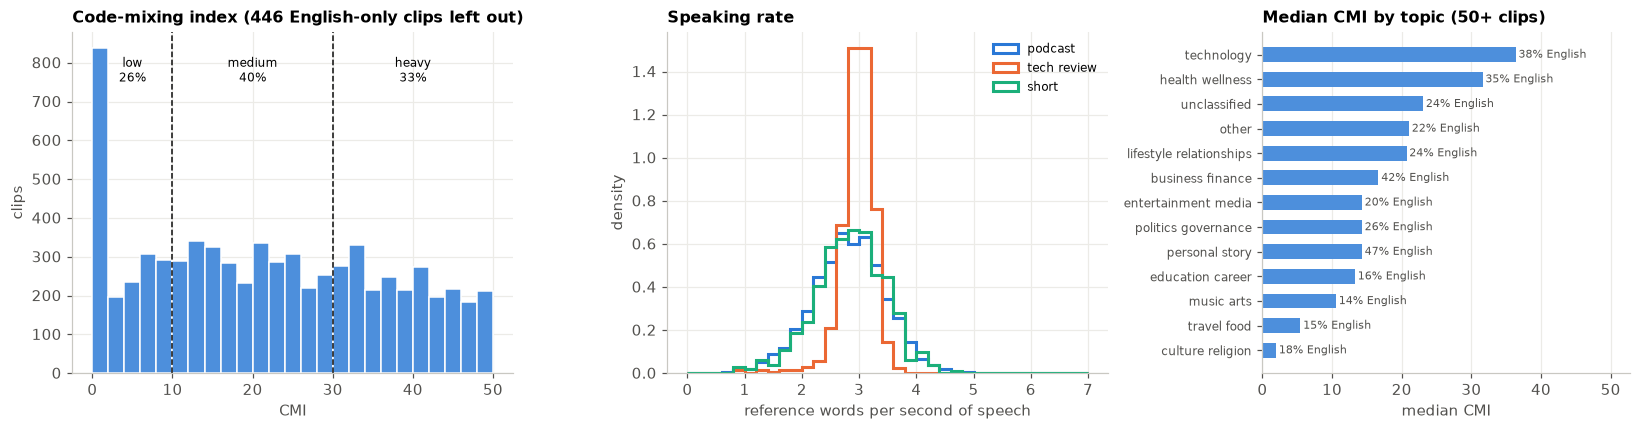

,clips,hours,English words %,podcast %,median words/s,share %
cmi_tier,,,,,,
Low (<10),1869,5.80,10.74,90.74,2.71,24.74
Medium (10-30),2871,10.47,25.98,86.90,2.94,38.00
Heavy (>=30),2369,9.53,43.33,73.03,2.95,31.36
English only,446,0.85,100.00,98.65,2.53,5.90


31.2% of reference words are English (Latin script); mean CMI 20.6, median 19.6; median rate 2.87 words/s (podcasts 2.84, tech reviews 2.99, reels 2.85)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), gridspec_kw={"width_ratios": [1.2, 1.2, 1]})
ax = axes[0]
mixed = scored[scored.cmi_tier != "English only"]
bins = np.arange(0, 52, 2)
ax.hist(mixed.cmi, bins=bins, color="#4d8fdc", edgecolor="white")
for x in (10, 30):
    ax.axvline(x, color=INK, lw=1, ls="--")
for x0, x1, name in ((0, 10, "low"), (10, 30, "medium"), (30, 50, "heavy")):
    share = ((mixed.cmi >= x0) & (mixed.cmi < x1 if x1 < 50 else mixed.cmi <= 50)).mean()
    ax.text((x0 + x1) / 2, ax.get_ylim()[1] * 0.93, f"{name}\n{share:.0%}", ha="center", va="top", fontsize=8)
ax.set(title=f"Code-mixing index ({len(scored) - len(mixed)} English-only clips left out)", xlabel="CMI", ylabel="clips")

ax = axes[1]
bins = np.arange(0, 7.1, 0.2)
for g_ in GENRES:
    ax.hist(scored.rate[scored.genre == g_].clip(upper=7), bins=bins, density=True, histtype="step", lw=2,
            color=GENRE_COLOR[g_], label=g_.replace("_", " "))
ax.set(title="Speaking rate", xlabel="reference words per second of speech", ylabel="density")
ax.legend(fontsize=8)

ax = axes[2]
by_topic = scored.groupby("topic").agg(cmi=("cmi", "median"), lat=("n_lat", "sum"), dev=("n_dev", "sum"), clips=("cmi", "size"))
by_topic = by_topic[by_topic.clips >= 50].sort_values("cmi")
ax.barh(by_topic.index, by_topic.cmi, color="#4d8fdc", height=0.6)
for y, (t_, r) in enumerate(by_topic.iterrows()):
    ax.text(r.cmi + 0.4, y, f"{100 * r.lat / (r.lat + r.dev):.0f}% English", va="center", fontsize=7.5, color=MUTED)
ax.set(title="Median CMI by topic (50+ clips)", xlabel="median CMI")
ax.set_yticks(range(len(by_topic)), [i.replace("_", " ") for i in by_topic.index], fontsize=8)
ax.set_xlim(0, by_topic.cmi.max() * 1.45)
ax.grid(axis="y", visible=False)
fig.tight_layout()
save(fig, "06_language")
plt.show()

mix = pd.DataFrame({
    "clips": scored.groupby("cmi_tier").size(),
    "hours": scored.groupby("cmi_tier").duration.sum() / 3600,
    "English words %": 100 * scored.groupby("cmi_tier").n_lat.sum() / (scored.groupby("cmi_tier").n_dev.sum() + scored.groupby("cmi_tier").n_lat.sum()),
    "podcast %": 100 * scored.groupby("cmi_tier").genre.apply(lambda s: (s == "podcast").mean()),
    "median words/s": scored.groupby("cmi_tier").rate.median(),
}).reindex(TIERS)
mix["share %"] = 100 * mix.clips / mix.clips.sum()
display(mix)
lat = scored.n_lat.sum() / (scored.n_lat.sum() + scored.n_dev.sum())
print(f"{lat:.1%} of reference words are English (Latin script); mean CMI {scored.cmi.mean():.1f}, median {scored.cmi.median():.1f}; "
      f"median rate {scored.rate.median():.2f} words/s (podcasts {scored.rate[scored.genre == 'podcast'].median():.2f}, "
      f"tech reviews {scored.rate[scored.genre == 'tech_review'].median():.2f}, reels {scored.rate[scored.genre == 'short'].median():.2f})")

## 7. How the labels were made

Every clip's seed is the fused transcript (D74). The queue ranked clips by how likely the fusion
was catastrophically wrong, using the disagreement between the three recognisers and a set of
flags; a clip low on that signal could be **screened**, accepted without being played (D63,
D65). Gold refuses screened labels. The disagreement rate is the share of reference words on which
the recognisers differ, and it is what separates the two tiers below.

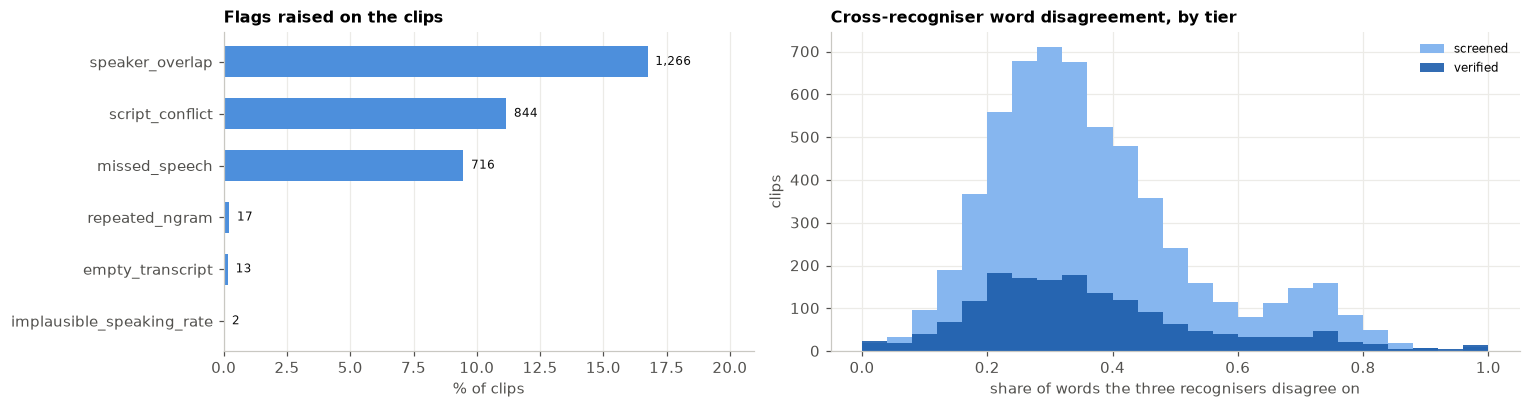

clips  edited  uncertain / unusable  median disagreement  flagged %
split tier                                                                         
train screened   5335       0                     0                 0.34      34.58
      verified   1105       3                    23                 0.37      38.73
val   screened    540       0                     0                 0.30      32.22
      verified     95       0                     0                 0.35      38.95
gold  verified    506      23                     1                 0.29      11.46

26 of 1,706 verified labels were edited (1.5%); gold: 23 of 506. The seed's WER of 0.00% is the same fact in words.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8), gridspec_kw={"width_ratios": [1, 1.3]})
ax = axes[0]
flag_counts = Counter(f for fl in usable.flag_list for f in fl)
fl = pd.Series(flag_counts).sort_values()
ax.barh(fl.index, 100 * fl / len(usable), color="#4d8fdc", height=0.6)
for y, v in enumerate(fl):
    ax.text(100 * v / len(usable) + 0.3, y, f"{v:,}", va="center", fontsize=8, color=INK)
ax.set(title="Flags raised on the clips", xlabel="% of clips")
ax.set_xlim(0, 100 * fl.max() / len(usable) * 1.25)
ax.grid(axis="y", visible=False)

ax = axes[1]
bins = np.arange(0, 1.01, 0.04)
for tier, color in (("screened", "#86b6ef"), ("verified", "#1c5cab")):
    ax.hist(usable.disagreement[usable.tier == tier].dropna(), bins=bins, color=color, label=tier, alpha=0.9 if tier == "verified" else 1)
ax.set(title="Cross-recogniser word disagreement, by tier", xlabel="share of words the three recognisers disagree on", ylabel="clips")
ax.legend(fontsize=8)
fig.tight_layout()
save(fig, "07_labels")
plt.show()

labels = pd.DataFrame({
    "clips": seg.groupby(["split", "tier"]).size(),
    "edited": seg.groupby(["split", "tier"]).disposition.apply(lambda s: int((s == "edited").sum())),
    "uncertain / unusable": seg.groupby(["split", "tier"]).disposition.apply(lambda s: int(s.isin(["uncertain", "unusable_audio"]).sum())),
    "median disagreement": seg.groupby(["split", "tier"]).disagreement.median(),
    "flagged %": 100 * seg.groupby(["split", "tier"]).flag_list.apply(lambda s: (s.str.len() > 0).mean()),
}).reindex(SPLITS, level=0)
display(labels)
ver = seg[seg.tier == "verified"]
print(f"{int((ver.disposition == 'edited').sum())} of {len(ver):,} verified labels were edited ({(ver.disposition == 'edited').mean():.1%}); "
      f"gold: {int((ver.disposition[ver.split == 'gold'] == 'edited').sum())} of {int((ver.split == 'gold').sum())}. "
      f"The seed's WER of {overall.loc['Fusion (seed)', 'WER %']:.2f}% is the same fact in words.")

## 8. The recognisers, by split and along every clip class

**By split**, with 95% intervals that resample **voices**, not clips: clips of one voice share a
microphone, a room and a way of talking, and 119 voices are far fewer independent draws than
7,500 clips. Gold is the number to quote: its voices speak nowhere else and every clip was heard.

**Along every class**, two readings side by side. The pooled WER per bucket is what a consumer
of the corpus would see, but buckets are filled by different episodes (crosstalk lives in
podcasts, and podcasts are harder anyway), so the table also gives the **within-episode rate
ratio**: each episode's clips in the bucket against the same episode's clips in the baseline,
pooled over episodes (Mantel-Haenszel), with an interval that resamples episodes. That is the
Models page's statistic (D87). A ratio whose interval holds 1 is a condition ruled out for that
recogniser.

WER %  raw WER %  CER %  WER lo  WER hi  clips
split system                                                       
train Scribe         10.63      19.62  10.12    8.43   13.11   6415
      Gemini          9.85      20.93  10.97    7.66   12.07   6415
      MAI            10.78      19.57  10.71    7.85   13.78   6415
      Fusion (seed)   0.00       0.19   0.00    0.00    0.00   6415
val   Scribe          8.27      16.36   9.16    5.70   10.03    635
      Gemini          6.34      15.76   7.26    5.14    7.36    635
      MAI             8.03      21.88  13.54    3.91   11.53    635
      Fusion (seed)   0.00       0.15   0.00    0.00    0.00    635
gold  Scribe          6.68      15.37   6.96    5.60    7.72    505
      Gemini          6.16      17.84   8.75    5.25    7.16    505
      MAI             5.81      14.24   7.61    4.85    6.82    505
      Fusion (seed)   0.03       0.64   0.14    0.00    0.07    505

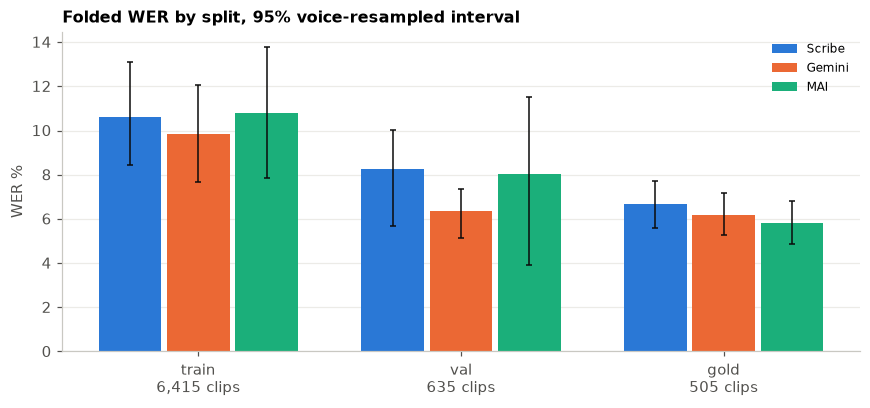

In [11]:
by_split = pd.concat({s: wer_table(scored[scored.split == s], systems=list(SHORT)) for s in SPLITS})
by_split.index.names = ["split", "system"]
by_split = by_split.join(scored.groupby("split").size().rename("clips"), on="split")
display(by_split)

fig, ax = plt.subplots(figsize=(8, 3.8))
x = np.arange(len(SPLITS))
wd = 0.26
for k, s in enumerate(SYSTEMS):
    v = by_split.xs(SHORT[s], level="system").reindex(SPLITS)
    ax.bar(x + (k - 1) * wd, v["WER %"], wd * 0.92, color=SYS_COLOR[s], label=SHORT[s],
           yerr=np.vstack([v["WER %"] - v["WER lo"], v["WER hi"] - v["WER %"]]),
           error_kw={"elinewidth": 1, "capsize": 2, "ecolor": INK})
ax.set_xticks(x, [f"{s}\n{by_split.xs(SHORT[SYSTEMS[0]], level='system').clips[s]:,} clips" for s in SPLITS])
ax.set(title="Folded WER by split, 95% voice-resampled interval", ylabel="WER %")
ax.grid(axis="x", visible=False)
ax.legend(fontsize=8)
fig.tight_layout()
save(fig, "08_wer_by_split")
plt.show()

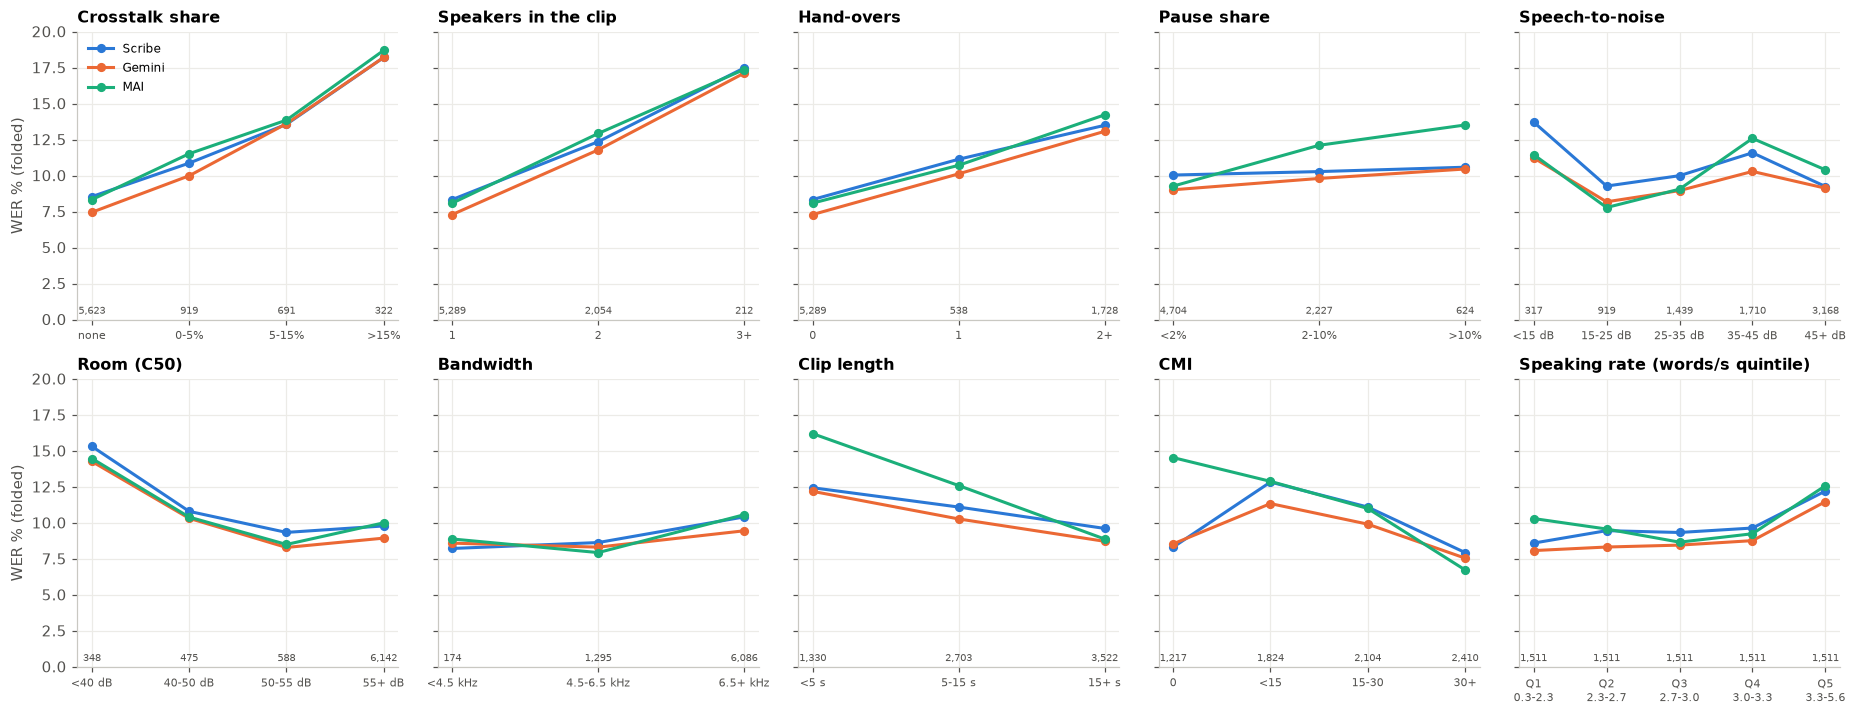

clips  Scribe WER  Gemini WER  MAI WER       Scribe ratio       Gemini ratio           MAI ratio
axis                             bucket                                                                                                       
Crosstalk share                  none          5623        8.54        7.45     8.33           baseline           baseline            baseline
                                 0-5%           919       10.87        9.99    11.52  1.04 [0.94, 1.18]  1.15 [1.04, 1.31]   1.18 [1.07, 1.30]
                                 5-15%          691       13.57       13.61    13.86  1.30 [1.23, 1.42]  1.59 [1.40, 1.94]   1.42 [1.29, 1.60]
                                 >15%           322       18.21       18.21    18.71  1.75 [1.39, 2.04]  2.22 [1.68, 2.74]   2.12 [1.62, 2.49]
Speakers in the clip             1             5289        8.34        7.30     8.09           baseline           baseline            baseline
                                 2             2054       12.36       11.79    12.93  1.15 [1.03, 1.34]  1.28 [1.15, 1.51]   1.20 [1.10, 1.33]
                                 3+             212       17.48       17.12    17.37  1.99 [1.54, 8.62]  2.59 [1.56, 2.71]  2.46 [2.35, 18.58]
Hand-overs                       0             5289        8.34        7.30     8.09           baseline           baseline            baseline
                                 1              538       11.14       10.12    10.72  1.04 [0.91, 1.23]  1.12 [0.99, 1.31]   1.01 [0.91, 1.17]
                                 2+            1728       13.49       13.08    14.22  1.24 [1.08, 1.47]  1.42 [1.20, 1.69]   1.34 [1.18, 1.54]
Pause share                      <2%           4704       10.04        9.02     9.27           baseline           baseline            baseline
                                 2-10%         2227       10.28        9.80    12.11  0.91 [0.82, 0.99]  0.92 [0.86, 0.97]   1.01 [0.89, 1.15]
                                 >10%           624       10.58       10.46    13.52  0.95 [0.83, 1.02]  1.01 [0.80, 1.14]   1.20 [1.06, 1.48]
Speech-to-noise                  <15 dB         317       13.72       11.23    11.46  1.67 [0.92, 2.93]  1.65 [0.97, 2.98]   1.53 [0.83, 2.72]
                                 15-25 dB       919        9.27        8.18     7.78  1.42 [1.06, 1.91]  1.56 [1.10, 2.16]   1.31 [0.88, 1.80]
                                 25-35 dB      1439       10.00        8.96     9.06  1.34 [1.27, 1.49]  1.43 [1.24, 1.80]   1.28 [1.04, 1.59]
                                 35-45 dB      1710       11.59       10.29    12.59  1.13 [1.05, 1.25]  1.21 [1.08, 1.42]   1.26 [1.11, 1.36]
                                 45+ dB        3168        9.24        9.13    10.40           baseline           baseline            baseline
Room (C50)                       <40 dB         348       15.32       14.27    14.47  1.54 [1.28, 2.59]  1.57 [0.83, 1.82]   1.58 [1.47, 3.02]
                                 40-50 dB       475       10.80       10.32    10.40  1.09 [0.97, 1.24]  1.17 [0.93, 1.40]   1.15 [1.01, 1.40]
                                 50-55 dB       588        9.34        8.29     8.50  1.09 [0.99, 1.25]  1.07 [0.99, 1.20]   1.15 [1.04, 1.32]
                                 55+ dB        6142        9.79        8.94    10.00           baseline           baseline            baseline
Bandwidth                        <4.5 kHz       174        8.22        8.59     8.88  0.80 [0.71, 0.98]  0.94 [0.69, 1.30]   0.91 [0.70, 1.18]
                                 4.5-6.5 kHz   1295        8.63        8.32     7.94  0.92 [0.81, 1.02]  1.01 [0.91, 1.11]   0.93 [0.86, 1.04]
                                 6.5+ kHz      6086       10.42        9.45    10.57           baseline           baseline            baseline
Clip length                      <5 s          1330       12.44       12.19    16.20  1.20 [1.01, 1.34]  1.27 [1.09, 1.45]   1.41 [1.30, 1.64]
                                 5-15 s   

buckets whose within-episode ratio excludes 1 for all three recognisers:
  Crosstalk share                    5-15%        Scribe 1.30  Gemini 1.59  MAI 1.42
  Crosstalk share                    >15%         Scribe 1.75  Gemini 2.22  MAI 2.12
  Speakers in the clip               2            Scribe 1.15  Gemini 1.28  MAI 1.20
  Speakers in the clip               3+           Scribe 1.99  Gemini 2.59  MAI 2.46
  Hand-overs                         2+           Scribe 1.24  Gemini 1.42  MAI 1.34
  Speech-to-noise                    25-35 dB     Scribe 1.34  Gemini 1.43  MAI 1.28
  Speech-to-noise                    35-45 dB     Scribe 1.13  Gemini 1.21  MAI 1.26
  Clip length                        <5 s         Scribe 1.20  Gemini 1.27  MAI 1.41


In [12]:
QN = 5
scored["rate_q"] = pd.qcut(scored.rate, QN, labels=[f"Q{i + 1}" for i in range(QN)]).astype(str)
edges = scored.groupby("rate_q").rate.agg(["min", "max"])
RATE_LABELS = {q: f"{q} {edges.loc[q, 'min']:.1f}-{edges.loc[q, 'max']:.1f}" for q in edges.index}
CLASS_AXES = {**AXES, "rate_q": ("Speaking rate (words/s quintile)", list(edges.index))}
BASELINE = {"c_overlap": "none", "c_speakers": "1", "c_turn_changes": "0", "c_pause": "<2%", "c_snr": "45+ dB",
            "c_reverb": "55+ dB", "c_bandwidth": "6.5+ kHz", "c_duration": "5-15 s", "c_cmi": "0", "rate_q": "Q3"}


def mh_ratio(frame, col, bucket, baseline, err, n_boot=1000, seed=0):
    """Within-episode error-rate ratio of ``bucket`` against ``baseline`` (Mantel-Haenszel over
    episodes), with a 95% interval that resamples episodes."""
    g = frame.groupby(["episode", col]).agg(e=(err, "sum"), w=("words", "sum"))
    try:
        j = g.xs(bucket, level=1).join(g.xs(baseline, level=1), lsuffix="_b", rsuffix="_0", how="inner")
    except KeyError:
        return np.nan, np.nan, np.nan, 0
    if len(j) < 2:
        return np.nan, np.nan, np.nan, len(j)
    t = (j.w_b + j.w_0).to_numpy()
    num, den = (j.e_b * j.w_0).to_numpy() / t, (j.e_0 * j.w_b).to_numpy() / t
    pick = np.random.default_rng(seed).integers(0, len(j), size=(n_boot, len(j)))
    boot = num[pick].sum(axis=1) / np.maximum(den[pick].sum(axis=1), 1e-9)
    return num.sum() / max(den.sum(), 1e-9), *np.percentile(boot, [2.5, 97.5]), len(j)


fig, axes = plt.subplots(2, 5, figsize=(17, 6.6), sharey=True)
ratio_rows = []
for ax, (col, (title, buckets)) in zip(axes.flat, CLASS_AXES.items()):
    present = [b for b in buckets if (scored[col] == b).sum() >= 30]
    n = scored.groupby(col).size().reindex(present)
    for s in SYSTEMS:
        w = [100 * scored.loc[scored[col] == b, f"{s}|werr"].sum() / scored.words[scored[col] == b].sum() for b in present]
        ax.plot(range(len(present)), w, marker="o", ms=5, lw=2, color=SYS_COLOR[s], label=SHORT[s])
        for b in present:
            r, lo, hi, n_ep = mh_ratio(scored, col, b, BASELINE[col], f"{s}|werr")
            ratio_rows.append({"axis": title, "col": col, "raw": b, "bucket": RATE_LABELS.get(b, b), "system": SHORT[s], "clips": int(n[b]),
                               "WER %": w[present.index(b)], "ratio": r, "lo": lo, "hi": hi, "episodes": n_ep})
    ax.set_xticks(range(len(present)), [RATE_LABELS.get(b, b).replace(" ", "\n", 1) if col == "rate_q" else b for b in present], fontsize=7.5)
    ax.set_title(title)
    ax.set_ylim(0, 20)
    for i, b in enumerate(present):
        ax.text(i, 0.4, f"{n[b]:,}", ha="center", fontsize=6.5, color=MUTED)
axes[0, 0].legend(fontsize=8, loc="upper left")
for ax in axes[:, 0]:
    ax.set_ylabel("WER % (folded)")
fig.tight_layout()
save(fig, "09_wer_by_class")
plt.show()

ratios = pd.DataFrame(ratio_rows)
ratios["ratio [95% CI]"] = ["baseline" if r.raw == BASELINE[r.col] else "-" if np.isnan(r.ratio)
                            else f"{r.ratio:.2f} [{r.lo:.2f}, {r.hi:.2f}]" for r in ratios.itertuples()]
wide = ratios.pivot_table(index=["axis", "bucket"], columns="system", values=["WER %"], aggfunc="first", sort=False)
wide.columns = [f"{s} WER" for _, s in wide.columns]
for s in SHORT.values():
    if s in set(ratios.system):
        wide[f"{s} ratio"] = ratios[ratios.system == s].set_index(["axis", "bucket"])["ratio [95% CI]"]
wide.insert(0, "clips", ratios[ratios.system == "Scribe"].set_index(["axis", "bucket"]).clips)
order = [(title, RATE_LABELS.get(b, b)) for col, (title, buckets) in CLASS_AXES.items() for b in buckets]
display(wide.reindex([k for k in order if k in wide.index]))

splits_ = ratios[(ratios.lo > 1) | (ratios.hi < 1)]
print("buckets whose within-episode ratio excludes 1 for all three recognisers:")
for (axis, bucket), sub in splits_.groupby(["axis", "bucket"], sort=False):
    if len(sub) == 3:
        print(f"  {axis:<34} {bucket:<12} " + "  ".join(f"{r.system} {r.ratio:.2f}" for _, r in sub.iterrows()))

**Crosstalk and the podcasts are nearly the same clips**, and so are heavy mixing and the tech
reviews, so the same two axes restricted to podcasts separate the condition from the genre.

In [13]:
pod = scored[scored.genre == "podcast"]
for col, title in (("c_overlap", "crosstalk share"), ("cmi_tier", "CMI tier")):
    buckets = AXES[col][1] if col in AXES else TIERS
    t = pd.concat({b: wer_table(pod[pod[col] == b]) for b in buckets if (pod[col] == b).sum() >= 50})
    print(f"podcasts only - WER % by {title} (voice CI):")
    display(t["WER %"].unstack().reindex([b for b in buckets if b in t.index.levels[0]]).round(1)
            .join(pod.groupby(col).size().rename("clips")))
rho = {SHORT[s]: {"all clips": spearmanr(scored.rate, scored[f"{s}|werr"] / scored.words)[0],
                  **{f"within {t_}": spearmanr(scored.rate[scored.cmi_tier == t_],
                                               (scored[f"{s}|werr"] / scored.words)[scored.cmi_tier == t_])[0] for t_ in TIERS[:3]}}
       for s in SYSTEMS}
print("Spearman rank correlation, speaking rate vs per-clip WER (positive = faster is worse):")
display(pd.DataFrame(rho).T.round(2))

podcasts only - WER % by crosstalk share (voice CI):


,Scribe,Gemini,MAI,clips
none,10.00,8.80,10.60,4503
0-5%,11.20,10.20,12.00,869
5-15%,13.60,13.70,14.00,670
>15%,18.20,18.20,18.70,319


podcasts only - WER % by CMI tier (voice CI):


,Scribe,Gemini,MAI,clips
Low (<10),13.30,11.60,13.20,1696
Medium (10-30),12.60,11.30,12.80,2495
Heavy (>=30),9.40,9.40,8.90,1730
English only,2.40,6.20,22.70,440


Spearman rank correlation, speaking rate vs per-clip WER (positive = faster is worse):


,all clips,within Low (<10),within Medium (10-30),within Heavy (>=30)
Scribe,0.21,0.21,0.25,0.15
Gemini,0.19,0.20,0.24,0.11
MAI,0.12,0.19,0.21,0.10


## 9. From voice to voice

The same WER for every voice with at least 10 minutes of speech. The spread between people is
the variation a held-out test set has to sample, which is why gold is sized in voices rather than
hours (docs/findings.md).

In [14]:
big = SPK.index[SPK.talk_min >= 10]
per_voice = pd.concat({v: wer_table(scored[scored.voice == v], cluster=None)["WER %"] for v in big}).unstack().round(1)
per_voice = SPK.loc[big, ["talk_min", "split", "gender", "age", "show"]].join(per_voice)
per_voice["crosstalk %"] = (100 * scored.groupby("voice").overlap_s.sum() / scored.groupby("voice").duration.sum()).reindex(big).round(1)
per_voice["CMI"] = scored.groupby("voice").cmi.mean().reindex(big).round(1)
per_voice["words/s"] = scored.groupby("voice").rate.median().reindex(big).round(2)
display(per_voice)
best = per_voice[[SHORT[s] for s in SYSTEMS]]
print(f"per-voice WER spans {best.min(axis=1).min():.1f}-{best.max(axis=1).max():.1f}% over {len(big)} voices; "
      f"the best recogniser differs by voice: {best.idxmin(axis=1).value_counts().to_dict()}")
print(f"Spearman(crosstalk %, WER) across these voices: "
      + ", ".join(f"{SHORT[s]} {spearmanr(per_voice['crosstalk %'], per_voice[SHORT[s]])[0]:.2f}" for s in SYSTEMS))

,talk_min,split,gender,age,show,Scribe,Gemini,MAI,crosstalk %,CMI,words/s
voice,,,,,,,,,,,
v001,219.06,"train, val",female,20_39,"other podcasts, tech reviews",4.90,3.80,2.30,0.10,36.20,3.00
v003,118.19,train,male,20_39,ep_NNN podcast,12.00,13.10,12.90,6.40,30.40,3.18
v008,79.76,"train, val",male,40_59,On Air with Sanjay,12.50,9.80,11.70,3.90,21.70,3.06
v007,62.14,train,male,60_79,On Air with Sanjay,18.30,11.50,16.60,1.90,12.30,2.78
v024,54.67,train,male,unresolved,other podcasts,4.80,6.10,7.50,1.20,24.50,2.36
v002,53.79,train,male,20_39,ep_NNN podcast,20.70,18.80,21.90,1.30,20.60,3.42
v006,53.60,train,male,20_39,ep_NNN podcast,9.10,9.70,10.40,0.10,11.50,2.73
v005,49.93,train,female,40_59,ep_NNN podcast,5.40,8.80,17.30,0.80,13.20,2.28
v009,49.68,train,male,20_39,On Air with Sanjay,12.90,12.50,11.50,1.10,11.00,2.94


per-voice WER spans 2.3-21.9% over 30 voices; the best recogniser differs by voice: {'Gemini': 16, 'MAI': 7, 'Scribe': 7}
Spearman(crosstalk %, WER) across these voices: Scribe 0.58, Gemini 0.57, MAI 0.31


## 10. What it says

Printed from the frames above, so a rerun on a newer export rewrites it.

In [15]:
tot_h = usable.duration.sum() / 3600
g_h = {k: v / 3600 for k, v in sec["gender"].items()}
lines = [
    f"CORPUS   {len(usable):,} clips, {tot_h:.2f} h, {usable.episode.nunique()} episodes, {len(SPK)} voices; "
    + ", ".join(f"{s} {at_a_glance.loc[s, 'hours']:.1f} h / {int(at_a_glance.loc[s, 'clips']):,} clips / {int(at_a_glance.loc[s, 'voices'])} voices" for s in SPLITS) + ".",
    f"         {len(shared)} voices speak on both sides of the gold line; gold is {at_a_glance.loc['gold', 'verified %']:.0f}% verified, "
    f"train {at_a_glance.loc['train', 'verified %']:.0f}%.",
    f"SOURCES  " + ", ".join(f"{g_.replace('_', ' ')} {hours(usable, 'genre').get(g_, 0) / tot_h:.0%}" for g_ in GENRES)
    + f"; {topic_h.index.size} topics, largest {topic_h.sum(axis=1).idxmax().replace('_', ' ')} ({topic_h.sum(axis=1).max() / tot_h:.0%}).",
    f"VOICES   largest {SPK['share %'].iloc[0]:.0f}% of speech, top 5 {SPK['share %'].head(5).sum():.0f}%; "
    + " / ".join(f"{k} {g_h.get(k, 0) / sum(g_h.values()):.0%}" for k in ("female", "male", "unresolved")) + " of talk time.",
    f"TALK     crosstalk in {len(ov) / len(usable):.0%} of clips, {100 * usable.overlap_s.sum() / usable.duration.sum():.1f}% of audio "
    + "(" + ", ".join(f"{s} {100 * usable.overlap_s[usable.split == s].sum() / usable.duration[usable.split == s].sum():.1f}%" for s in SPLITS) + "); "
    f"{(usable.c_speakers != '1').mean():.0%} of clips have a second voice.",
    f"SOUND    median SNR {usable.snr_db.median():.0f} dB, C50 {usable.c50_db.median():.0f} dB, bandwidth {usable.bandwidth_hz.median() / 1000:.1f} kHz; "
    f"{(usable.c_snr.isin(['<15 dB', '15-25 dB'])).mean():.0%} of clips under 25 dB SNR, {(usable.c_bandwidth != '6.5+ kHz').mean():.0%} band-limited.",
    f"MIXING   {lat:.0%} of words are English; " + ", ".join(f"{t_.split(' (')[0].lower()} {mix.loc[t_, 'share %']:.0f}%" for t_ in TIERS) + " of clips.",
    f"LABELS   {int((ver.disposition == 'edited').sum())} of {len(ver):,} verified labels edited; seed WER {overall.loc['Fusion (seed)', 'WER %']:.2f}%.",
    "WER      (folded; train / val / gold)",
]
for s in SYSTEMS:
    lines.append(f"         {SHORT[s]:<7} " + " / ".join(f"{by_split.loc[(sp, SHORT[s]), 'WER %']:.1f}" for sp in SPLITS)
                 + f"   gold 95% CI [{by_split.loc[('gold', SHORT[s]), 'WER lo']:.1f}, {by_split.loc[('gold', SHORT[s]), 'WER hi']:.1f}]")
lines += [
    "CLASSES  within-episode ratio excludes 1 for all three: "
    + "; ".join(f"{axis.split(' (')[0].lower()} {bucket}" for (axis, bucket), sub in splits_.groupby(["axis", "bucket"], sort=False) if len(sub) == 3),
    f"SPREAD   per-voice WER {best.min(axis=1).min():.1f}-{best.max(axis=1).max():.1f}% over {len(big)} voices with 10+ min.",
    "CAVEAT   references are the fused transcript of these three recognisers; gold was heard, most of train was screened.",
]
print("\n".join(lines))

CORPUS   7,557 clips, 26.65 h, 126 episodes, 125 voices; train 22.3 h / 6,417 clips / 30 voices, val 2.2 h / 635 clips / 5 voices, gold 2.2 h / 505 clips / 87 voices.
         0 voices speak on both sides of the gold line; gold is 100% verified, train 17%.
SOURCES  podcast 79%, tech review 13%, short 8%; 15 topics, largest health wellness (16%).
VOICES   largest 15% of speech, top 5 36%; female 34% / male 53% / unresolved 13% of talk time.
TALK     crosstalk in 26% of clips, 2.9% of audio (train 3.3%, val 1.1%, gold 0.5%); 30% of clips have a second voice.
SOUND    median SNR 42 dB, C50 59 dB, bandwidth 7.8 kHz; 16% of clips under 25 dB SNR, 19% band-limited.
MIXING   31% of words are English; low 25%, medium 38%, heavy 31%, english only 6% of clips.
LABELS   26 of 1,706 verified labels edited; seed WER 0.00%.
WER      (folded; train / val / gold)
         Scribe  10.6 / 8.3 / 6.7   gold 95% CI [5.6, 7.7]
         Gemini  9.9 / 6.3 / 6.2   gold 95% CI [5.3, 7.2]
         MAI     10.8 /